In [6]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

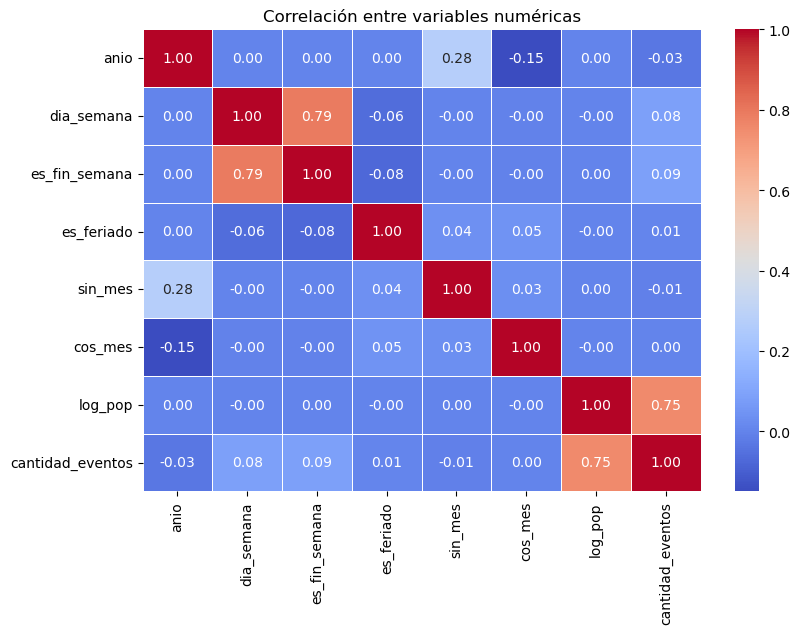

In [12]:
# === 1. Cargar datos
df = pd.read_parquet("../data/ecu911_emergencias_limpio.parquet")
df_poblacion = pd.read_csv("../data/poblacion_provincias_ecuador_2022.csv")

# Asegurar tipos
df['fecha'] = pd.to_datetime(df['fecha'])

# === 2. Agregar a nivel DÍA–PROVINCIA
df_modelo = (
    df.groupby(['fecha', 'provincia'], as_index=False)['cantidad_eventos']
      .sum()
)

# === 3. Unir población
df_modelo = df_modelo.merge(df_poblacion, on='provincia', how='left')

# === 4. Variables temporales
df_modelo['anio'] = df_modelo['fecha'].dt.year
df_modelo['mes'] = df_modelo['fecha'].dt.month
df_modelo['dia_semana'] = df_modelo['fecha'].dt.dayofweek       # 0=Lunes, 6=Domingo
df_modelo['es_fin_semana'] = df_modelo['dia_semana'].isin([5,6]).astype(int)

# === 5. Variable de feriado (ya tienes un campo en tu parquet)
# Si tu df original tiene 'es_feriado' diario, mejor usarlo:
feriados_dia = (
    df.groupby(['fecha'])['es_feriado']
      .max().reset_index()
)
df_modelo = df_modelo.merge(feriados_dia, on='fecha', how='left')
df_modelo['es_feriado'] = df_modelo['es_feriado'].fillna(0).astype(int)

# === 6. Variables cíclicas (estacionalidad mensual)
df_modelo['sin_mes'] = np.sin(2 * np.pi * df_modelo['mes'] / 12)
df_modelo['cos_mes'] = np.cos(2 * np.pi * df_modelo['mes'] / 12)

# === 7. Offset poblacional
df_modelo['log_pop'] = np.log(df_modelo['poblacion_2022'])

# === 8. Variables finales para modelado / correlación
cols_modelo = [
    'anio', 'dia_semana', 'es_fin_semana', 'es_feriado',
    'sin_mes', 'cos_mes', 'log_pop', 'cantidad_eventos'
]
df_corr = df_modelo[cols_modelo]

# === 9. Correlación solo numérica
corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(9,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlación entre variables numéricas")
plt.savefig("../reports/fig/correlacion.png", bbox_inches="tight", transparent=False)
plt.show()


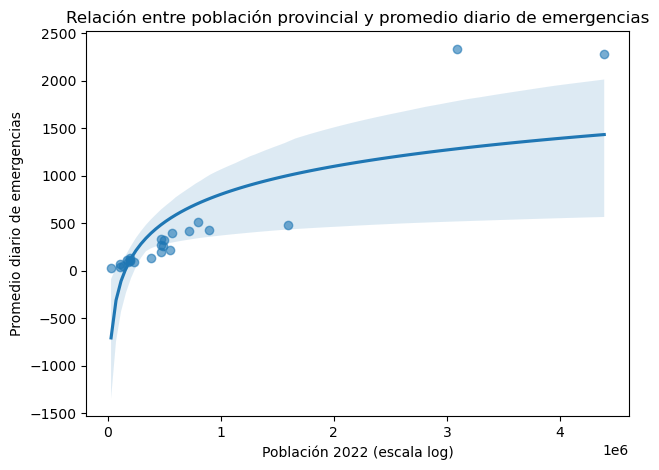

In [13]:
# Promedio diario de eventos por provincia
prov_mean = (
    df_modelo.groupby('provincia', as_index=False)
      .agg({'cantidad_eventos':'mean', 'poblacion_2022':'first'})
)

plt.figure(figsize=(7,5))
sns.regplot(data=prov_mean, x='poblacion_2022', y='cantidad_eventos', logx=True, scatter_kws={'alpha':0.6})
plt.xlabel("Población 2022 (escala log)")
plt.ylabel("Promedio diario de emergencias")
plt.title("Relación entre población provincial y promedio diario de emergencias")
plt.savefig("../reports/fig/log_rel.png", bbox_inches="tight", transparent=False)

plt.show()


In [9]:
fecha_min = df_modelo['fecha'].min()
fecha_max = df_modelo['fecha'].max()

split_point = fecha_min + (fecha_max - fecha_min) * 0.8
print(f"Punto de corte temporal (80/20): {split_point:%Y-%m-%d}")


Punto de corte temporal (80/20): 2024-10-30


In [10]:
mask_train = df_modelo['fecha'] < split_point
mask_test  = df_modelo['fecha'] >= split_point

train = df_modelo[mask_train]
test  = df_modelo[mask_test]

print(f"Train: {train['fecha'].min():%Y-%m-%d} → {train['fecha'].max():%Y-%m-%d}")
print(f"Test : {test['fecha'].min():%Y-%m-%d} → {test['fecha'].max():%Y-%m-%d}")


Train: 2021-07-01 → 2024-10-30
Test : 2024-10-31 → 2025-08-31


In [11]:
import statsmodels.api as sm
import patsy as pt
import numpy as np

# === 1️⃣ Fórmula
formula = (
    "cantidad_eventos ~ C(provincia) + es_fin_semana + C(dia_semana) + "
    "es_feriado + sin_mes + cos_mes + anio"
)

# === 2️⃣ Matrices de diseño (solo con TRAIN)
y_tr, X_tr = pt.dmatrices(formula, train, return_type='dataframe')
y_te, X_te = pt.dmatrices(formula, test, return_type='dataframe')

# === 3️⃣ Entrenar GLM Negativo Binomial
model_nb = sm.GLM(
    y_tr,
    X_tr,
    family=sm.families.NegativeBinomial(),
    offset=train['log_pop']
)
res_nb = model_nb.fit()
print(res_nb.summary())

# === 4️⃣ Predicciones y métricas
pred_train = res_nb.predict(X_tr, offset=train['log_pop'])
pred_test  = res_nb.predict(X_te, offset=test['log_pop'])

rmse_train = np.sqrt(np.mean((train['cantidad_eventos'] - pred_train)**2))
rmse_test  = np.sqrt(np.mean((test['cantidad_eventos']  - pred_test)**2))
nrmse_test = rmse_test / test['cantidad_eventos'].mean()

print(f"RMSE Train: {rmse_train:.2f}")
print(f"RMSE Test : {rmse_test:.2f}  |  nRMSE: {nrmse_test:.3f}")


/home/brandon/micromamba/envs/DS/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:       cantidad_eventos   No. Observations:                29222
Model:                            GLM   Df Residuals:                    29188
Model Family:        NegativeBinomial   Df Model:                           33
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.8520e+05
Date:                Fri, 17 Oct 2025   Deviance:                       1014.5
Time:                        23:11:57   Pearson chi2:                     865.
No. Iterations:                    28   Pseudo R-squ. (CS):            0.09199
Covariance Type:            nonrobust                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [ ]:
import pickle

# --- Guardar con pickle
with open("../data/modelo_neg_binomial.pkl", "wb") as f:
    pickle.dump(res_nb, f)

# --- (alternativa)
res_nb.save("../data/modelo_neg_binomial.sm")


In [14]:
# Predicción diaria por provincia
test["pred_nb"] = res_nb.predict(X_te, offset=test["log_pop"])

# (opcional) si deseas guardar el conjunto de test con predicciones
#test.to_parquet("predicciones_test_diario.parquet", index=False)


In [15]:
test

,fecha,provincia,cantidad_eventos,poblacion_2022,anio,mes,dia_semana,es_fin_semana,es_feriado,sin_mes,cos_mes,log_pop,pred_nb
29222,2024-10-31,Azuay,571,801609.0,2024,10,3,0,0,-0.866025,0.5,13.594376,435.152931
29223,2024-10-31,Bolivar,108,199078.0,2024,10,3,0,0,-0.866025,0.5,12.201452,81.933700
29224,2024-10-31,Carchi,107,172828.0,2024,10,3,0,0,-0.866025,0.5,12.060052,95.779543
29225,2024-10-31,Cañar,91,227578.0,2024,10,3,0,0,-0.866025,0.5,12.335248,82.690279
29226,2024-10-31,Chimborazo,227,471933.0,2024,10,3,0,0,-0.866025,0.5,13.064592,228.700383
...,...,...,...,...,...,...,...,...,...,...,...,...,...
36537,2025-08-31,Santa Elena,182,385735.0,2025,8,6,1,0,-0.866025,-0.5,12.862906,159.181069
36538,2025-08-31,Santo Domingo De Los Tsachilas,417,492969.0,2025,8,6,1,0,-0.866025,-0.5,13.108202,372.523419
36539,2025-08-31,Sucumbios,152,199014.0,2025,8,6,1,0,-0.866025,-0.5,12.201130,154.103300
36540,2025-08-31,Tungurahua,471,563532.0,2025,8,6,1,0,-0.866025,-0.5,13.241979,454.867283


In [16]:
df_pred = (
    test.groupby("fecha", as_index=False)
        .agg({"cantidad_eventos": "sum", "pred_nb": "sum"})
)

print(df_pred.head())


       fecha  cantidad_eventos       pred_nb
0 2024-10-31              9247   7955.829847
1 2024-11-01             10018   9747.645752
2 2024-11-02              9831  10049.698132
3 2024-11-03             10245  11356.832231
4 2024-11-04              7640   8906.147967


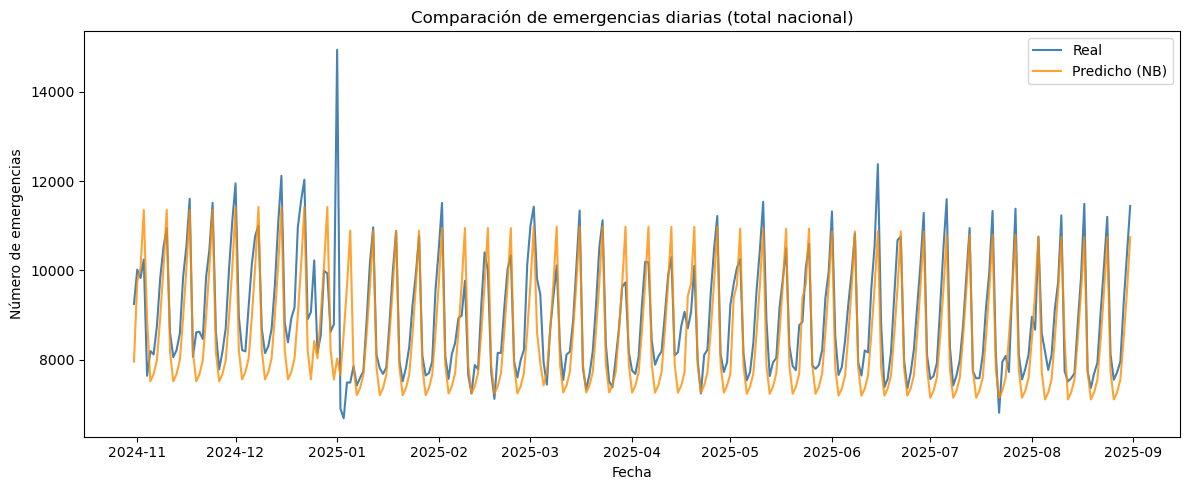

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df_pred["fecha"], df_pred["cantidad_eventos"], label="Real", color="steelblue")
plt.plot(df_pred["fecha"], df_pred["pred_nb"], label="Predicho (NB)", color="darkorange", alpha=0.8)
plt.title("Comparación de emergencias diarias (total nacional)")
plt.xlabel("Fecha")
plt.ylabel("Número de emergencias")
plt.legend()
plt.tight_layout()
plt.show()


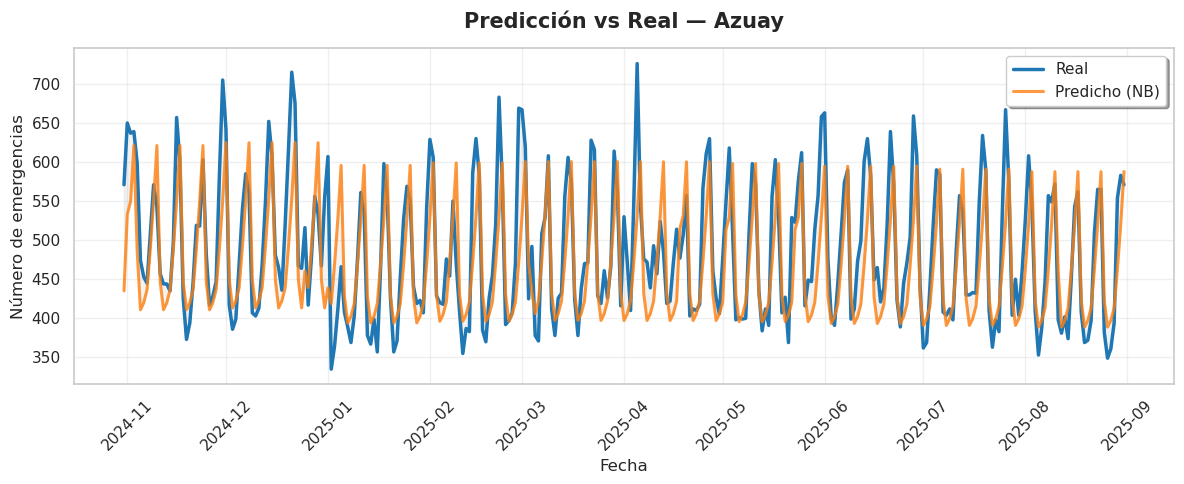

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

prov = "Azuay"
df_prov = test[test["provincia"] == prov].copy()

# Estilo general
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Línea real
plt.plot(
    df_prov["fecha"],
    df_prov["cantidad_eventos"],
    label="Real",
    color="#1f77b4",
    linewidth=2.5,
)

# Línea predicha con suavizado visual
plt.plot(
    df_prov["fecha"],
    df_prov["pred_nb"],
    label="Predicho (NB)",
    color="#ff7f0e",
    linewidth=2.2,
    alpha=0.8,
)

# Relleno para suavizar diferencia
plt.fill_between(
    df_prov["fecha"],
    df_prov["cantidad_eventos"],
    df_prov["pred_nb"],
    color="gray",
    alpha=0.1,
)

# Personalización
plt.title(f"Predicción vs Real — {prov}", fontsize=15, weight="bold", pad=15)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Número de emergencias", fontsize=12)
plt.xticks(rotation=45)
plt.legend(frameon=True, shadow=True, fontsize=11, loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()

# Guardar y mostrar
plt.savefig("../reports/fig/azuay_mejorado.png", dpi=300, bbox_inches="tight")
plt.show()


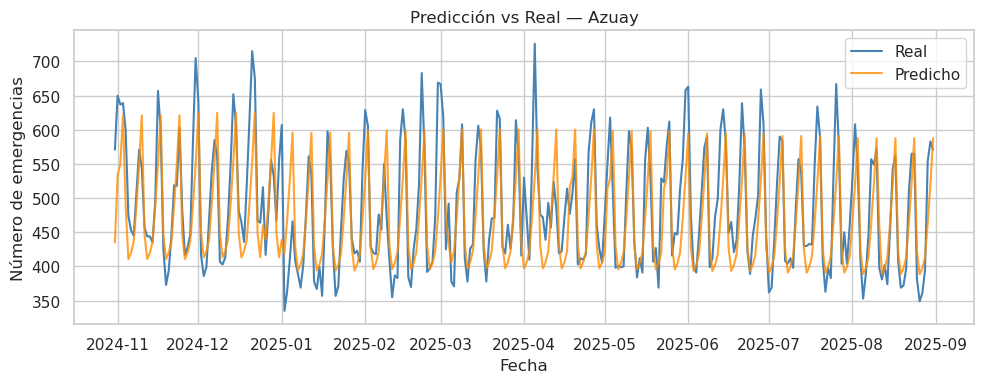

In [20]:
prov = "Azuay"
df_prov = test[test["provincia"] == prov].copy()

plt.figure(figsize=(10,4))
plt.plot(df_prov["fecha"], df_prov["cantidad_eventos"], label="Real", color="steelblue")
plt.plot(df_prov["fecha"], df_prov["pred_nb"], label="Predicho", color="darkorange", alpha=0.8)
plt.title(f"Predicción vs Real — {prov}")
plt.xlabel("Fecha")
plt.ylabel("Número de emergencias")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/fig/azuay.png", bbox_inches="tight", transparent=False)
plt.show()


In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x="cantidad_eventos", y="pred_nb", data=test, alpha=0.5)
plt.plot([0, test["cantidad_eventos"].max()],
         [0, test["cantidad_eventos"].max()], color="red", ls="--")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Ajuste del modelo NB por provincia–día")
plt.tight_layout()
plt.show()


In [ ]:
prov_error = (
    test.groupby("provincia", as_index=False)
        .apply(lambda g: np.sqrt(np.mean((g["cantidad_eventos"] - g["pred_nb"])**2)))
        .rename(columns={None: "RMSE"})
)
prov_error = prov_error.sort_values("RMSE")
print(prov_error.head())


In [ ]:
import pandas as pd
import numpy as np
import patsy as pt

def predecir_incidentes_provincia(provincia, start_date, end_date, modelo, df_poblacion, provincias_entrenadas):
    """
    Predice el total esperado de incidentes para una provincia y rango de fechas.
    
    provincia: str, ej. "Azuay"
    start_date, end_date: rango de fechas (ej. "2025-01-01", "2025-03-31")
    modelo: modelo GLM entrenado (res_nb)
    df_poblacion: df con columnas ['provincia', 'poblacion_2022']
    provincias_entrenadas: lista de provincias usadas en el entrenamiento
    """
    # --- Generar calendario
    fechas = pd.date_range(start=start_date, end=end_date, freq="D")
    df_futuro = pd.DataFrame({"fecha": fechas})
    
    # --- Validar provincia
    if provincia not in provincias_entrenadas:
        raise ValueError(f"La provincia '{provincia}' no fue parte del entrenamiento.")
    
    # --- Obtener población
    pop_row = df_poblacion[df_poblacion["provincia"] == provincia]
    if pop_row.empty:
        raise ValueError(f"No se encontró población para '{provincia}'.")
    pop = pop_row["poblacion_2022"].values[0]
    
    # --- Variables base
    df_futuro["provincia"] = provincia
    df_futuro["poblacion_2022"] = pop
    df_futuro["log_pop"] = np.log(pop)
    df_futuro["anio"] = df_futuro["fecha"].dt.year
    df_futuro["mes"] = df_futuro["fecha"].dt.month
    df_futuro["dia_semana"] = df_futuro["fecha"].dt.dayofweek
    df_futuro["es_fin_semana"] = df_futuro["dia_semana"].isin([5, 6]).astype(int)
    df_futuro["es_feriado"] = 0
    df_futuro["sin_mes"] = np.sin(2 * np.pi * df_futuro["mes"] / 12)
    df_futuro["cos_mes"] = np.cos(2 * np.pi * df_futuro["mes"] / 12)

    # --- Mantener las categorías originales
    cat_dtype = pd.api.types.CategoricalDtype(categories=provincias_entrenadas)
    df_futuro["provincia"] = df_futuro["provincia"].astype(cat_dtype)
    
    # --- Crear matriz de diseño (solo X, sin Y)
    rhs_formula = "C(provincia) + es_fin_semana + C(dia_semana) + es_feriado + sin_mes + cos_mes + anio"
    X_fut = pt.dmatrix(rhs_formula, df_futuro, return_type="dataframe")
    
    # --- Predicción
    df_futuro["pred_nb"] = modelo.predict(X_fut, offset=df_futuro["log_pop"])
    total = df_futuro["pred_nb"].sum()
    
    return df_futuro[["fecha", "provincia", "pred_nb"]], total


In [ ]:
provincias_entrenadas = sorted(train["provincia"].unique().tolist())

df_pred_azuay, total_azuay = predecir_incidentes_provincia(
    provincia="Azuay",
    start_date="2025-01-07",
    end_date="2025-03-31",
    modelo=res_nb,
    df_poblacion=df_poblacion,
    provincias_entrenadas=provincias_entrenadas
)

print(f"✅ Total estimado de emergencias en Azuay (ene–mar 2025): {total_azuay:,.0f}")


In [ ]:
total_azuay

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df_pred_azuay["fecha"], df_pred_azuay["pred_nb"], color="darkorange")
plt.title("Predicción esperada — Azuay (modelo NB)")
plt.xlabel("Fecha")
plt.ylabel("Emergencias estimadas")
plt.tight_layout()
plt.show()
